## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("spambase.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
X = df.iloc[:, :-1].values   # first 57 columns
y = df.iloc[:, -1].values    # last column

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Problem 1

In [6]:
# Training logistic regression model
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [7]:
y_test_pred = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_test_pred)
acc = accuracy_score(y_test, y_test_pred)
err = 1 - acc
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Confusion Matrix:
 [[667  30]
 [ 53 401]]
Accuracy: 0.9278887923544744
Error: 0.07211120764552559
Precision: 0.9303944315545244
Recall: 0.8832599118942731
F1: 0.9062146892655367


In [8]:
coefs = pd.DataFrame({
    "feature": np.arange(X.shape[1]),
    "coefficient": log_reg.coef_[0]
})

coefs_sorted = coefs.sort_values(by="coefficient", key=abs, ascending=False)
coefs_sorted.head(15)

,feature,coefficient
26,26,-3.800026
24,24,-2.305496
55,55,1.732458
34,34,-1.641654
40,40,-1.630044
33,33,-1.603259
41,41,-1.572990
45,45,-1.523850
52,52,1.374809
28,28,-1.349269


In [9]:
thresholds = [0.25, 0.5, 0.75, 0.9]
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

rows = []
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0)
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,accuracy,precision,recall
0,0.25,0.907037,0.833013,0.955947
1,0.50,0.927889,0.930394,0.883260
2,0.75,0.897480,0.956522,0.775330
3,0.90,0.847089,0.989437,0.618943


## Problem 2

In [13]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

Xb_train = add_bias(X_train_scaled)
Xb_test = add_bias(X_test_scaled)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    
def cross_entropy_loss(X, y, theta):
    eps = 1e-12
    h = sigmoid(X @ theta)
    h = np.clip(h, eps, 1 - eps)
    return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

def logistic_gradient_descent(X, y, alpha, num_iters):
    n, d = X.shape
    theta = np.zeros(d)
    losses = []

    for i in range(num_iters):
        h = sigmoid(X @ theta)
        grad = (1 / n) * (X.T @ (h - y))
        theta = theta - alpha * grad
        losses.append(cross_entropy_loss(X, y, theta))

    return theta, losses

In [14]:
learning_rates = [0.001, 0.01, 0.1]
iters_to_check = [10, 50, 100]

results = []

for alpha in learning_rates:
    theta, losses = logistic_gradient_descent(Xb_train, y_train, alpha, 100)

    for it in iters_to_check:
        results.append({
            "learning_rate": alpha,
            "iterations": it,
            "cross_entropy_loss": losses[it - 1]
        })

loss_table = pd.DataFrame(results)
loss_table

,learning_rate,iterations,cross_entropy_loss
0,0.001,10,0.688603
1,0.001,50,0.671304
2,0.001,100,0.651502
3,0.010,10,0.651338
4,0.010,50,0.542090
5,0.010,100,0.469330
6,0.100,10,0.465983
7,0.100,50,0.325163
8,0.100,100,0.289826


In [15]:
metric_rows = []

for alpha in learning_rates:
    theta, losses = logistic_gradient_descent(Xb_train, y_train, alpha, 100)

    train_probs = sigmoid(Xb_train @ theta)
    test_probs = sigmoid(Xb_test @ theta)

    train_pred = (train_probs >= 0.5).astype(int)
    test_pred = (test_probs >= 0.5).astype(int)

    metric_rows.append({
        "learning_rate": alpha,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "train_precision": precision_score(y_train, train_pred, zero_division=0),
        "train_recall": recall_score(y_train, train_pred, zero_division=0),
        "train_f1": f1_score(y_train, train_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
    })

gd_metrics = pd.DataFrame(metric_rows)
gd_metrics

,learning_rate,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,0.001,0.899420,0.870425,0.874908,0.872661,0.891399,0.858388,0.867841,0.863089
1,0.010,0.900290,0.883598,0.860191,0.871738,0.896612,0.873051,0.863436,0.868217
2,0.100,0.910725,0.915415,0.852097,0.882622,0.903562,0.905437,0.843612,0.873432


In [16]:
train_pkg_pred = log_reg.predict(X_train_scaled)
test_pkg_pred = log_reg.predict(X_test_scaled)

print("Package Logistic Regression")
print("Train Accuracy:", accuracy_score(y_train, train_pkg_pred))
print("Train Precision:", precision_score(y_train, train_pkg_pred))
print("Train Recall:", recall_score(y_train, train_pkg_pred))
print("Train F1:", f1_score(y_train, train_pkg_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pkg_pred))
print("Test Precision:", precision_score(y_test, test_pkg_pred))
print("Test Recall:", recall_score(y_test, test_pkg_pred))
print("Test F1:", f1_score(y_test, test_pkg_pred))

Package Logistic Regression
Train Accuracy: 0.9292753623188406
Train Precision: 0.9285165257494236
Train Recall: 0.8888888888888888
Train F1: 0.9082706766917293
Test Accuracy: 0.9278887923544744
Test Precision: 0.9303944315545244
Test Recall: 0.8832599118942731
Test F1: 0.9062146892655367


## Problem 3

In [17]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_rows = []

for k in k_values:
    accs, errs, precs, recs = [], [], [], []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        y_val_pred = knn.predict(X_val)

        acc = accuracy_score(y_val, y_val_pred)
        accs.append(acc)
        errs.append(1 - acc)
        precs.append(precision_score(y_val, y_val_pred, zero_division=0))
        recs.append(recall_score(y_val, y_val_pred, zero_division=0))

    knn_cv_rows.append({
        "k": k,
        "avg_accuracy": np.mean(accs),
        "avg_error": np.mean(errs),
        "avg_precision": np.mean(precs),
        "avg_recall": np.mean(recs)
    })

knn_cv_results = pd.DataFrame(knn_cv_rows)
knn_cv_results

,k,avg_accuracy,avg_error,avg_precision,avg_recall
0,1,0.906087,0.093913,0.882413,0.878590
1,3,0.905797,0.094203,0.884013,0.875635
2,5,0.906667,0.093333,0.897339,0.861664
3,7,0.905797,0.094203,0.898437,0.857977
4,9,0.907536,0.092464,0.903768,0.856509
5,11,0.900580,0.099420,0.897762,0.844006
6,15,0.896522,0.103478,0.901036,0.828557


In [18]:
best_k = knn_cv_results.loc[knn_cv_results["avg_error"].idxmin(), "k"]
best_k

9

In [19]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=int(best_k))
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=9)

In [20]:
def classifier_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    return {
        "accuracy": acc,
        "error": 1 - acc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0)
    }

rows = []

models = {
    "Logistic Regression": log_reg,
    "LDA": lda,
    "kNN": knn
}

for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_metrics = classifier_metrics(y_train, train_pred)
    test_metrics = classifier_metrics(y_test, test_pred)

    rows.append({
        "model": name,
        "dataset": "train",
        **train_metrics
    })
    rows.append({
        "model": name,
        "dataset": "test",
        **test_metrics
    })

comparison_results = pd.DataFrame(rows)
comparison_results

,model,dataset,accuracy,error,precision,recall
0,Logistic Regression,train,0.929275,0.070725,0.928517,0.888889
1,Logistic Regression,test,0.927889,0.072111,0.930394,0.883260
2,LDA,train,0.891014,0.108986,0.918298,0.793966
3,LDA,test,0.884448,0.115552,0.910486,0.784141
4,kNN,train,0.920580,0.079420,0.918919,0.875644
5,kNN,test,0.906169,0.093831,0.893182,0.865639


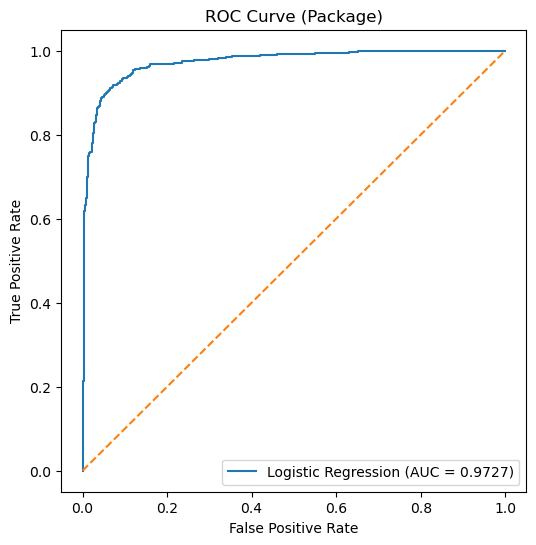

AUC: 0.9727055536945627


In [21]:
y_test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
auc_value = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Package)")
plt.legend()
plt.show()

print("AUC:", auc_value)

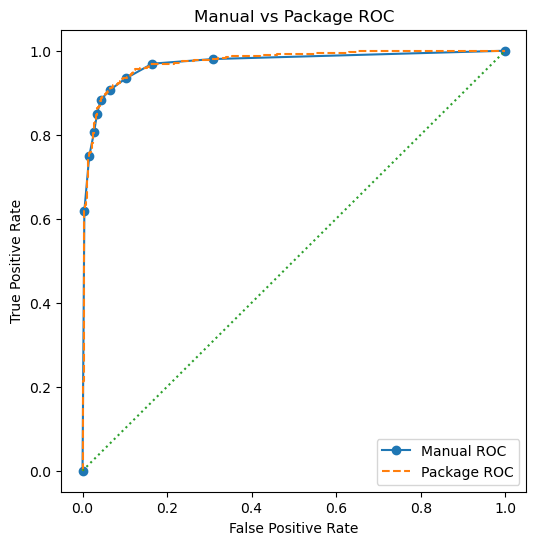

In [22]:
manual_thresholds = np.arange(0, 1.01, 0.1)

manual_fpr = []
manual_tpr = []

for t in manual_thresholds:
    y_pred_t = (y_test_probs >= t).astype(int)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    manual_fpr.append(fpr_val)
    manual_tpr.append(tpr_val)

plt.figure(figsize=(6, 6))
plt.plot(manual_fpr, manual_tpr, marker='o', label="Manual ROC")
plt.plot(fpr, tpr, linestyle="--", label="Package ROC")
plt.plot([0, 1], [0, 1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual vs Package ROC")
plt.legend()
plt.show()

## Problem 4

In [23]:
def make_folds(X, y, k):
    n = len(y)
    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)

    folds = np.array_split(indices, k)
    return folds

In [24]:
def k_fold_cv_error(model_class, X, y, k, **model_kwargs):
    folds = make_folds(X, y, k)
    errors = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # scale inside each fold to avoid leakage
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        error = 1 - accuracy_score(y_val, y_pred)
        errors.append(error)

    return np.mean(errors)

In [25]:
cv_rows = []

for k in [5, 10]:
    log_err = k_fold_cv_error(LogisticRegression, X, y, k, max_iter=5000, random_state=42)
    lda_err = k_fold_cv_error(LinearDiscriminantAnalysis, X, y, k)

    cv_rows.append({
        "model": "Logistic Regression",
        "k_folds": k,
        "avg_validation_error": log_err
    })

    cv_rows.append({
        "model": "LDA",
        "k_folds": k,
        "avg_validation_error": lda_err
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

,model,k_folds,avg_validation_error
0,Logistic Regression,5,0.075200
1,LDA,5,0.112583
2,Logistic Regression,10,0.073897
3,LDA,10,0.112801
